In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import cluster
from sklearn import feature_selection
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
train = pd.read_csv('/kaggle/input/datasets/cfvargasf/ny-dataset/train.csv')
print("Shape:", train.shape) 
print("Taxi dataset loaded successfully.")

Shape: (1458644, 11)
Taxi dataset loaded successfully.


In [4]:
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])

print("Pickup datetime converted successfully.") 

Pickup datetime converted successfully.


In [5]:
train['pickup_datetime'].describe() 

count                          1458644
mean     2016-04-01 10:10:24.940037120
min                2016-01-01 00:00:17
25%      2016-02-17 16:46:04.249999872
50%                2016-04-01 17:19:40
75%      2016-05-15 03:56:08.750000128
max                2016-06-30 23:59:39
Name: pickup_datetime, dtype: object

In [6]:
train.isnull().sum()
print("Initial missing-value check completed.")

Initial missing-value check completed.


In [7]:
train.info()
print("Initial dataset structure checked.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 122.4+ MB
Initial dataset structure checked.


In [8]:
train['dropoff_datetime'].value_counts() 
print("Dropoff datetime frequency checked.")

Dropoff datetime frequency checked.


In [9]:
train['trip_duration'].median()  
print("Median trip duration checked.")

Median trip duration checked.


In [10]:
print(' Minimum Trip Duration:', round(train['trip_duration'].min(),0), 'sec,', 'Maximum Trip Duration:', round(train['trip_duration'].max(),0), 'sec') 
print("Trip duration range checked.")

 Minimum Trip Duration: 1 sec, Maximum Trip Duration: 3526282 sec
Trip duration range checked.


In [11]:
# ваш код здесь
def add_datetime_features(data):
    data['pickup_date'] = data['pickup_datetime'].dt.date
    data['pickup_hour'] = data['pickup_datetime'].dt.hour
    data['pickup_day_of_week'] = data['pickup_datetime'].dt.day_name()
    return data

In [12]:
train = add_datetime_features(train)
print("Datetime features created successfully.")

Datetime features created successfully.


In [13]:
NYC_LAT_MIN, NYC_LAT_MAX = 40.4, 41.0
NYC_LON_MIN, NYC_LON_MAX = -74.3, -73.6

before = len(train)

train = train[
    train['pickup_latitude'].between(NYC_LAT_MIN, NYC_LAT_MAX) &
    train['dropoff_latitude'].between(NYC_LAT_MIN, NYC_LAT_MAX) &
    train['pickup_longitude'].between(NYC_LON_MIN, NYC_LON_MAX) &
    train['dropoff_longitude'].between(NYC_LON_MIN, NYC_LON_MAX)
].copy() 

after = len(train)

print(f"Removed {before - after} records with coordinates outside the NYC bounding box.")
print(f"Remaining records: {after}")
print("Incorrect Coordinates (outside NYC area) are removed.")


Removed 620 records with coordinates outside the NYC bounding box.
Remaining records: 1458024
Incorrect Coordinates (outside NYC area) are removed.


In [14]:
def get_total_distance(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    EARTH_RADIUS = 6371

    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1

    d = (
        np.sin(lat_delta * 0.5) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    )

    return 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))


def get_angle_direction(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))

    lng_delta_rad = lng2 - lng1

    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = (
        np.cos(lat1) * np.sin(lat2)
        - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    )

    return np.degrees(np.arctan2(y, x))




print("Geographical features created successfully.")

Geographical features created successfully.


In [15]:
def add_geographical_features(data):
    data['total_distance'] = get_total_distance(
        data['pickup_latitude'],
        data['pickup_longitude'],
        data['dropoff_latitude'],
        data['dropoff_longitude']
    )

    data['direction'] = get_angle_direction(
        data['pickup_latitude'],
        data['pickup_longitude'],
        data['dropoff_latitude'],
        data['dropoff_longitude']
    )
    return data


In [16]:
train = add_geographical_features(train)
print("Geographical features added successfully.")

Geographical features added successfully.


In [17]:
before = len(train)

train = train[train['passenger_count'] > 0].copy()

after = len(train)

print(f"Removed {before - after} records with zero passengers.")
print(f"Remaining records: {after}")
print("Invalid passenger records removed successfully.")

Removed 60 records with zero passengers.
Remaining records: 1457964
Invalid passenger records removed successfully.


In [18]:
weather_data = pd.read_csv('/kaggle/input/datasets/jorawar128/weather-data-nyc/weatherdata.csv')

weather_data['timestamp'] = pd.to_datetime(weather_data['timestamp'])

weather_data['date'] = weather_data['timestamp'].dt.date
weather_data['hour'] = weather_data['timestamp'].dt.hour

weather_data = weather_data.sort_values('timestamp')

weather_data = weather_data.drop_duplicates(
    subset=['date', 'hour'],
    keep='first'
).copy()

print("Weather rows after duplicate removal:", len(weather_data))
print(
    "Remaining duplicate date-hour records:",
    weather_data.duplicated(['date', 'hour']).sum()
)
print("Weather dataset loaded and cleaned successfully.")

Weather rows after duplicate removal: 4356
Remaining duplicate date-hour records: 0
Weather dataset loaded and cleaned successfully.


In [19]:
print(train.columns.tolist())
print("Taxi dataset columns checked.")

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week', 'total_distance', 'direction']
Taxi dataset columns checked.


In [20]:
weather_columns = [
    'date',
    'hour',
    'temp',
    'windspeed',
    'humidity',
    'precip',
    'pressure',
    'conditions',
    'dailyprecip',
    'dailysnow',
    'fog'
]

train = train.merge(
    weather_data[weather_columns],
    left_on=['pickup_date', 'pickup_hour'],
    right_on=['date', 'hour'],
    how='left'
)

train = train.drop(['date', 'hour'], axis=1)

print("Taxi and weather datasets merged successfully.")
print("Merged dataset shape:", train.shape)

Taxi and weather datasets merged successfully.
Merged dataset shape: (1457964, 25)


In [21]:
print(train[['windspeed', 'pressure', 'dailyprecip', 'dailysnow', 'fog']].dtypes)

print("\nSample values:")
print(train[['windspeed', 'pressure', 'dailyprecip', 'dailysnow', 'fog']].head(10))

print("\nUnique values of dailyprecip:")
print(train['dailyprecip'].dropna().unique()[:20])

print("\nUnique values of dailysnow:")
print(train['dailysnow'].dropna().unique()[:20])

print("\nUnique values of fog:")
print(train['fog'].dropna().unique()[:20])

print("\nWeather column inspection completed successfully.")

windspeed      float64
pressure       float64
dailyprecip     object
dailysnow       object
fog            float64
dtype: object

Sample values:
   windspeed  pressure dailyprecip dailysnow  fog
0       13.8     30.00        0.29      0.00  0.0
1        3.5     29.72        0.00      0.00  0.0
2       16.1     29.99        0.00      0.00  0.0
3       10.4     30.06        0.00      0.00  0.0
4        6.9     30.31        0.00      0.00  0.0
5       10.4     29.99        0.00      0.00  0.0
6        3.5     30.11        0.00      0.00  0.0
7        NaN     30.15        0.04      0.00  0.0
8        6.9     30.06        0.00      0.00  0.0
9        4.6     29.89        0.00      0.00  0.0

Unique values of dailyprecip:
['0.29' '0.00' '0.04' 'T' '0.01' '0.45' '0.91' '0.09' '0.06' '0.44' '0.05'
 '0.25' '0.18' '0.73' '0.02' '0.07' '0.20' '0.24' '1.80' '0.14']

Unique values of dailysnow:
['0.00' 'T' '1.40' '0.20' '2.50' '0.40' '0.10' '26.60' '0.50']

Unique values of fog:
[0. 1.]

Weather co

In [22]:
def fill_null_weather_data(train):

    numeric_columns = [
        'temp',
        'windspeed',
        'humidity',
        'precip',
        'pressure'
    ]

    train[numeric_columns] = train[numeric_columns].fillna(
        train.groupby('pickup_date')[numeric_columns].transform('median')
    )

    train['conditions'] = train['conditions'].fillna('None')

    return train

print("Weather missing-value handling completed successfully.")

Weather missing-value handling completed successfully.


In [23]:
train = fill_null_weather_data(train)
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,direction,temp,windspeed,humidity,precip,pressure,conditions,dailyprecip,dailysnow,fog
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,99.970196,41.0,13.8,86.0,0.0,30.00,Overcast,0.29,0.00,0.0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,-117.153768,82.0,3.5,56.0,0.0,29.72,Unknown,0.00,0.00,0.0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,-159.680165,24.1,16.1,38.0,0.0,29.99,Clear,0.00,0.00,0.0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,-172.737700,44.1,10.4,55.0,0.0,30.06,Clear,0.00,0.00,0.0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,179.473585,54.0,6.9,40.0,0.0,30.31,Clear,0.00,0.00,0.0


In [24]:
before = len(train)

train = train[train['trip_duration'] <= 3 * 60 * 60].copy()

after = len(train)

print(f"Removed {before - after} trips longer than 3 hours.")
print(f"Remaining records: {after}")
print("Trip duration outliers removed successfully.")

Removed 2105 trips longer than 3 hours.
Remaining records: 1455859
Trip duration outliers removed successfully.


In [25]:
train['speed_kmh'] = (
    train['total_distance'] / (train['trip_duration'] / 3600)
)

before = len(train)

train = train[train['speed_kmh'] < 300].copy()

after = len(train)

train = train.drop(columns=['speed_kmh'])

print(f"Removed {before - after} trips with speed >= 300 km/h.")
print(f"Remaining records: {after}")
print("Trip speed outlier cleaning completed successfully.")

Removed 27 trips with speed >= 300 km/h.
Remaining records: 1455832
Trip speed outlier cleaning completed successfully.


In [26]:
# Convert trace precipitation/snow values to 0
train['dailyprecip'] = train['dailyprecip'].replace('T', '0')
train['dailysnow'] = train['dailysnow'].replace('T', '0')

# Convert to numeric
train['dailyprecip'] = pd.to_numeric(train['dailyprecip'], errors='coerce')
train['dailysnow'] = pd.to_numeric(train['dailysnow'], errors='coerce')

# Fill missing numeric weather values with median
numeric_weather = [
    'windspeed',
    'pressure',
    'dailyprecip',
    'dailysnow'
]

for col in numeric_weather:
    train[col] = train[col].fillna(train[col].median())
train['fog'] = train['fog'].fillna(0)

print("Missing fog values filled successfully.")
print("Weather numeric columns cleaned successfully.")

Missing fog values filled successfully.
Weather numeric columns cleaned successfully.


In [27]:
print("Final dataset shape:", train.shape)

print("\nRemaining null values:")
print(train.isnull().sum())

print("\nRemaining duplicate rows:", train.duplicated().sum())

print("\nCurrent columns:")
print(train.columns.tolist())

print("\nData cleaning and merging completed successfully.")

Final dataset shape: (1455832, 25)

Remaining null values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
pickup_date           0
pickup_hour           0
pickup_day_of_week    0
total_distance        0
direction             0
temp                  0
windspeed             0
humidity              0
precip                0
pressure              0
conditions            0
dailyprecip           0
dailysnow             0
fog                   0
dtype: int64

Remaining duplicate rows: 0

Current columns:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week', 'total_distance', 'direction', '

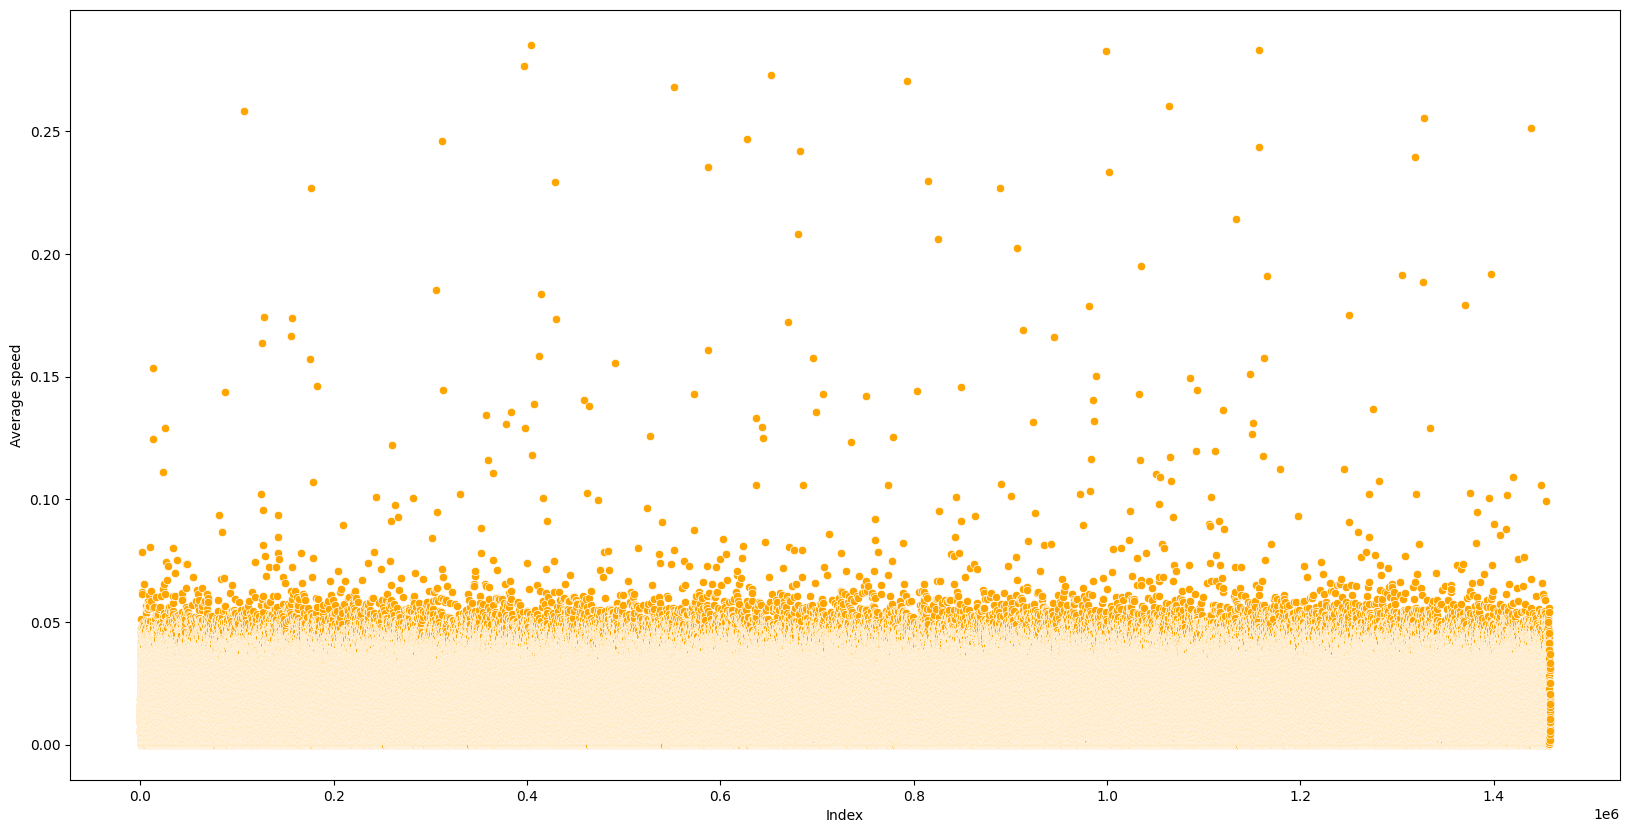

In [28]:
avg_speed = train['total_distance'] / train['trip_duration'] * 3.6
fig, ax = plt.subplots(figsize=(20, 10))
sns.scatterplot(x=avg_speed.index, y=avg_speed, ax=ax, color='orange')
ax.set_xlabel('Index')
ax.set_ylabel('Average speed');

In [29]:
print("========== FINAL DATASET CHECK ==========")

print("\n1. Shape:")
print(train.shape)

print("\n2. Data types:")
print(train.dtypes)

print("\n3. Missing values:")
print(train.isnull().sum())

print("\n4. Duplicate rows:")
print(train.duplicated().sum())

print("\n5. Target variable (trip_duration):")
print(train['trip_duration'].describe())

print("\n6. Infinite values:")
print(
    np.isinf(train.select_dtypes(include=np.number)).sum()
)

print("\n7. Unique values:")
print(train.nunique())

print("\n8. Final columns:")
print(train.columns.tolist())

print("\n========== CHECK COMPLETED ==========")

========== FINAL DATASET CHECK ==========

1. Shape:
(1455832, 25)

2. Data types:
id                            object
vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime              object
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
pickup_date                   object
pickup_hour                    int32
pickup_day_of_week            object
total_distance               float64
direction                    float64
temp                         float64
windspeed                    float64
humidity                     float64
precip                       float64
pressure                     float64
conditions                    object
dailyprecip                  float64
dailysnow                    float64
fog                          

In [30]:
train.to_csv('/kaggle/working/merged-Dataset.csv', index=False)

print("Cleaned merged dataset saved successfully.")

Cleaned merged dataset saved successfully.


In [31]:
print("Dataset Shape:", train.shape)

print("\nColumns:")
print(train.columns.tolist())

print("\nData Types:")
print(train.dtypes)

print("\nMissing Values:")
print(train.isnull().sum())

print("\nDuplicate Rows:", train.duplicated().sum())

print("\nEDA basic inspection completed successfully.")

Dataset Shape: (1455832, 25)

Columns:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week', 'total_distance', 'direction', 'temp', 'windspeed', 'humidity', 'precip', 'pressure', 'conditions', 'dailyprecip', 'dailysnow', 'fog']

Data Types:
id                            object
vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime              object
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
pickup_date                   object
pickup_hour                    int32
pickup_day_of_week            object
total_distance               float64
direction

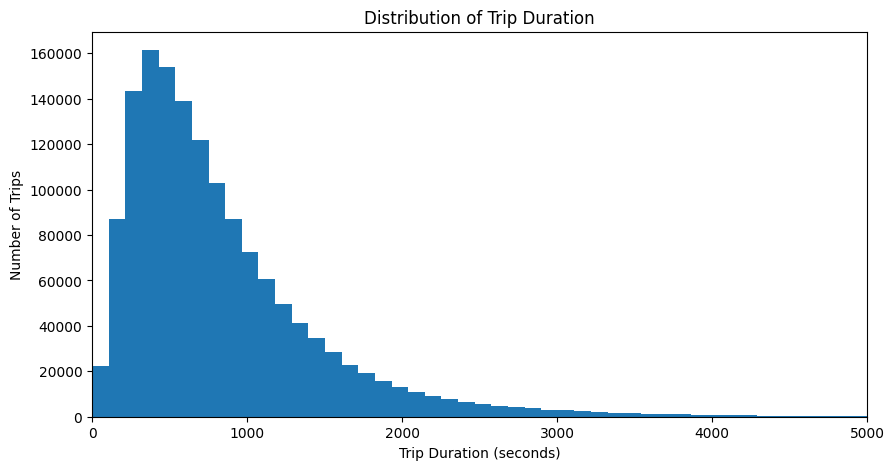

Trip duration distribution plotted successfully.


In [32]:
plt.figure(figsize=(10, 5))
plt.hist(train['trip_duration'], bins=100)
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration')
plt.xlim(0, 5000)
plt.show()

print("Trip duration distribution plotted successfully.")

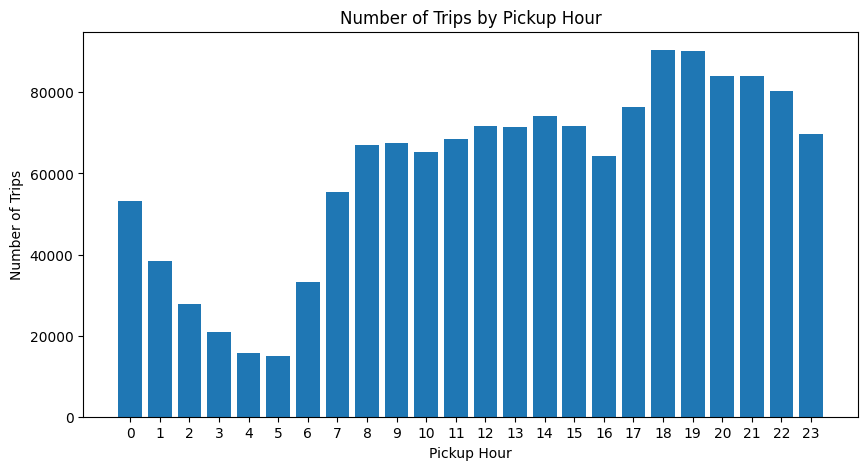

Hourly trip distribution plotted successfully.


In [33]:
hourly_trips = train['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(hourly_trips.index, hourly_trips.values)
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Pickup Hour')
plt.xticks(range(24))
plt.show()

print("Hourly trip distribution plotted successfully.")

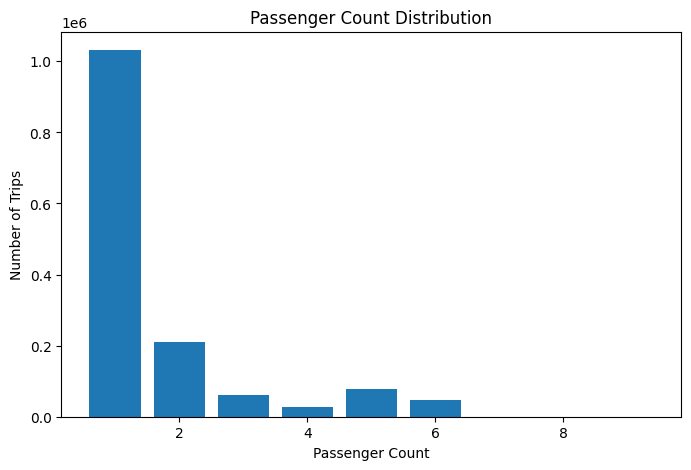

Passenger count distribution plotted successfully.


In [34]:
passenger_counts = train['passenger_count'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(passenger_counts.index, passenger_counts.values)
plt.xlabel('Passenger Count')
plt.ylabel('Number of Trips')
plt.title('Passenger Count Distribution')
plt.show()

print("Passenger count distribution plotted successfully.")

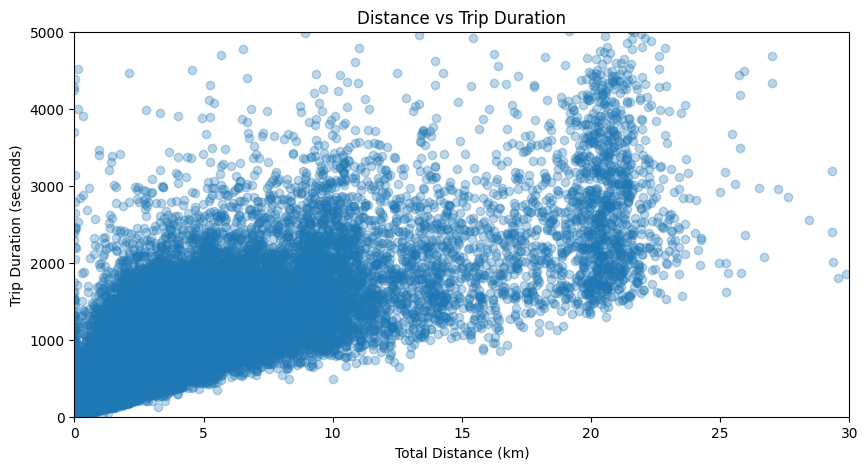

Distance vs trip duration analysis completed successfully.


In [35]:
sample = train.sample(50000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(
    sample['total_distance'],
    sample['trip_duration'],
    alpha=0.3
)
plt.xlabel('Total Distance (km)')
plt.ylabel('Trip Duration (seconds)')
plt.title('Distance vs Trip Duration')
plt.xlim(0, 30)
plt.ylim(0, 5000)
plt.show()

print("Distance vs trip duration analysis completed successfully.")

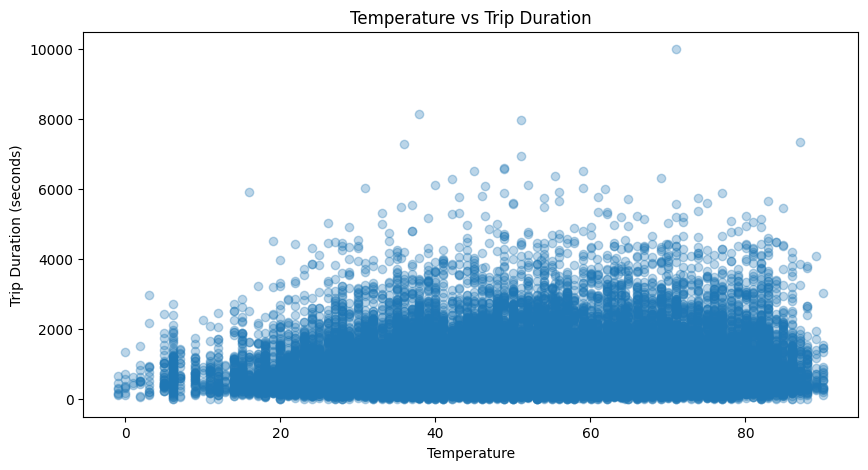

Weather vs trip duration analysis completed successfully.


In [36]:
weather_sample = train.sample(50000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(
    weather_sample['temp'],
    weather_sample['trip_duration'],
    alpha=0.3
)
plt.xlabel('Temperature')
plt.ylabel('Trip Duration (seconds)')
plt.title('Temperature vs Trip Duration')
plt.show()

print("Weather vs trip duration analysis completed successfully.")

In [37]:
numeric_cols = train.select_dtypes(include='number')

correlation = numeric_cols.corr()['trip_duration'].sort_values(ascending=False)

print(correlation)

print("\nCorrelation analysis completed successfully.")

trip_duration        1.000000
total_distance       0.769635
pickup_longitude     0.359414
dropoff_longitude    0.222768
temp                 0.073644
pickup_hour          0.029536
passenger_count      0.015079
vendor_id            0.008713
direction            0.004779
precip               0.003932
fog                  0.001376
dailysnow           -0.005020
windspeed           -0.008899
dailyprecip         -0.011764
pressure            -0.014343
humidity            -0.027128
dropoff_latitude    -0.184975
pickup_latitude     -0.234560
Name: trip_duration, dtype: float64

Correlation analysis completed successfully.


In [38]:
print("========== MODELING DATA CHECK ==========")

print("Dataset shape:", train.shape)

print("\nMissing values:", train.isnull().sum().sum())

print("Duplicate rows:", train.duplicated().sum())

print("\nTarget column present:", 'trip_duration' in train.columns)

print("\nModeling dataset check completed successfully.")

========== MODELING DATA CHECK ==========
Dataset shape: (1455832, 25)

Missing values: 0
Duplicate rows: 0

Target column present: True

Modeling dataset check completed successfully.


In [39]:
train['pickup_month'] = train['pickup_datetime'].dt.month

print("Pickup month feature created successfully.")
print("Unique pickup months:", sorted(train['pickup_month'].unique()))

Pickup month feature created successfully.
Unique pickup months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]


In [40]:
model_data = train[
    [
        'vendor_id',
        'passenger_count',
        'pickup_longitude',
        'pickup_latitude',
        'dropoff_longitude',
        'dropoff_latitude',
        'store_and_fwd_flag',
        'pickup_hour',
        'pickup_month',
        'pickup_day_of_week',
        'total_distance',
        'direction',
        'temp',
        'windspeed',
        'humidity',
        'precip',
        'pressure',
        'conditions',
        'dailyprecip',
        'dailysnow',
        'fog',
        'trip_duration'
    ]
].copy()
print("Model dataset shape:", model_data.shape)
print("\nModel columns:")
print(model_data.columns.tolist())
print("\nFeature selection completed successfully.")

Model dataset shape: (1455832, 22)

Model columns:
['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_month', 'pickup_day_of_week', 'total_distance', 'direction', 'temp', 'windspeed', 'humidity', 'precip', 'pressure', 'conditions', 'dailyprecip', 'dailysnow', 'fog', 'trip_duration']

Feature selection completed successfully.


In [41]:
X = model_data.drop('trip_duration', axis=1)
y = model_data['trip_duration']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget statistics:")
print(y.describe())

print("\nX and Y separation completed successfully.")

X shape: (1455832, 21)
y shape: (1455832,)

Target statistics:
count    1.455832e+06
mean     8.362391e+02
std      6.569905e+02
min      1.000000e+00
25%      3.970000e+02
50%      6.610000e+02
75%      1.072000e+03
max      1.073100e+04
Name: trip_duration, dtype: float64

X and y separation completed successfully.


In [42]:
X = pd.get_dummies(
    X,
    columns=['store_and_fwd_flag', 'pickup_day_of_week', 'conditions'],
    drop_first=False
)

print("X shape after encoding:", X.shape)
print("\nRemaining non-numeric columns:")
print(X.select_dtypes(exclude='number').columns.tolist())

print("\nCategorical encoding completed successfully.")

X shape after encoding: (1455832, 42)

Remaining non-numeric columns:
['store_and_fwd_flag_N', 'store_and_fwd_flag_Y', 'pickup_day_of_week_Friday', 'pickup_day_of_week_Monday', 'pickup_day_of_week_Saturday', 'pickup_day_of_week_Sunday', 'pickup_day_of_week_Thursday', 'pickup_day_of_week_Tuesday', 'pickup_day_of_week_Wednesday', 'conditions_Clear', 'conditions_Haze', 'conditions_Heavy Rain', 'conditions_Heavy Snow', 'conditions_Light Freezing Rain', 'conditions_Light Rain', 'conditions_Light Snow', 'conditions_Mostly Cloudy', 'conditions_None', 'conditions_Overcast', 'conditions_Partly Cloudy', 'conditions_Rain', 'conditions_Scattered Clouds', 'conditions_Snow', 'conditions_Unknown']

Categorical encoding completed successfully.


In [43]:
X = X.astype(float)

print("X shape:", X.shape)
print("All features numeric:", X.select_dtypes(exclude='number').columns.tolist() == [])

print("\nFinal feature data type check completed successfully.")

X shape: (1455832, 42)
All features numeric: True

Final feature data type check completed successfully.


In [44]:
print("Total columns:", len(X.columns))
print(X.columns.tolist())

Total columns: 42
['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_month', 'total_distance', 'direction', 'temp', 'windspeed', 'humidity', 'precip', 'pressure', 'dailyprecip', 'dailysnow', 'fog', 'store_and_fwd_flag_N', 'store_and_fwd_flag_Y', 'pickup_day_of_week_Friday', 'pickup_day_of_week_Monday', 'pickup_day_of_week_Saturday', 'pickup_day_of_week_Sunday', 'pickup_day_of_week_Thursday', 'pickup_day_of_week_Tuesday', 'pickup_day_of_week_Wednesday', 'conditions_Clear', 'conditions_Haze', 'conditions_Heavy Rain', 'conditions_Heavy Snow', 'conditions_Light Freezing Rain', 'conditions_Light Rain', 'conditions_Light Snow', 'conditions_Mostly Cloudy', 'conditions_None', 'conditions_Overcast', 'conditions_Partly Cloudy', 'conditions_Rain', 'conditions_Scattered Clouds', 'conditions_Snow', 'conditions_Unknown']


In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTrain-test split completed successfully.")

Training features shape: (1164665, 42)
Testing features shape: (291167, 42)
Training target shape: (1164665,)
Testing target shape: (291167,)

Train-test split completed successfully.


In [46]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


In [47]:
xgb_model.fit(
    X_train,
    y_train,
    verbose=True
)

print("XGBoost model training completed successfully.")

XGBoost model training completed successfully.


In [48]:
y_pred = xgb_model.predict(X_test)

print("Predictions generated successfully.")
print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nNumber of predictions:", len(y_pred))

Predictions generated successfully.

First 10 predictions:
[2614.6401   645.8368   486.1671  1154.756   1263.9648   239.43106
 1413.585    824.36005  240.58252  314.7229 ]

Number of predictions: 291167


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("========== XGBOOST MODEL PERFORMANCE ==========")
print(f"MAE  : {mae:.2f} seconds")
print(f"RMSE : {rmse:.2f} seconds")
print(f"R²   : {r2:.4f}")

print("\nModel evaluation completed successfully.")

========== XGBOOST MODEL PERFORMANCE ==========
MAE  : 175.39 seconds
RMSE : 283.93 seconds
R²   : 0.8148

Model evaluation completed successfully.


In [50]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("========== TOP 15 FEATURE IMPORTANCE ==========")
print(feature_importance.head(15))

print("\nFeature importance analysis completed successfully.")

========== TOP 15 FEATURE IMPORTANCE ==========
total_distance                  0.468670
pickup_day_of_week_Sunday       0.065270
pickup_hour                     0.053440
pickup_day_of_week_Saturday     0.045619
pickup_day_of_week_Monday       0.034324
dropoff_longitude               0.024661
pickup_longitude                0.024574
direction                       0.024232
pickup_latitude                 0.022957
dropoff_latitude                0.020564
pickup_day_of_week_Thursday     0.020342
pickup_month                    0.019686
pickup_day_of_week_Wednesday    0.014739
pickup_day_of_week_Friday       0.013890
conditions_Unknown              0.012724
dtype: float32

Feature importance analysis completed successfully.


In [51]:
print("========== TRIP DURATION DISTRIBUTION ==========")

print("Trips > 1 hour:", (y > 3600).sum())
print("Trips > 2 hours:", (y > 7200).sum())
print("Trips > 3 hours:", (y > 10800).sum())
print("Trips > 6 hours:", (y > 21600).sum())
print("Trips > 12 hours:", (y > 43200).sum())
print("Trips > 24 hours:", (y > 86400).sum())

print("\nPercentage of trips > 1 hour:",
      round((y > 3600).mean() * 100, 4), "%")

print("\nTrip duration distribution check completed successfully.")

========== TRIP DURATION DISTRIBUTION ==========
Trips > 1 hour: 10085
Trips > 2 hours: 137
Trips > 3 hours: 0
Trips > 6 hours: 0
Trips > 12 hours: 0
Trips > 24 hours: 0

Percentage of trips > 1 hour: 0.6927 %

Trip duration distribution check completed successfully.


In [52]:
comparison = pd.DataFrame({
    'Actual_duration': y_test.values,
    'Predicted_duration': y_pred
})

comparison['Error'] = (
    comparison['Actual_duration'] -
    comparison['Predicted_duration']
)

print("========== ACTUAL VS PREDICTED ==========")
print(comparison.head(10))

print("\nAverage actual duration:",
      round(comparison['Actual_duration'].mean(), 2), "seconds")

print("Average predicted duration:",
      round(comparison['Predicted_duration'].mean(), 2), "seconds")

print("\nActual vs predicted comparison completed successfully.")

========== ACTUAL VS PREDICTED ==========
   Actual_duration  Predicted_duration       Error
0             2432         2614.640137 -182.640137
1              570          645.836792  -75.836792
2              344          486.167114 -142.167114
3             1215         1154.755981   60.244019
4             1043         1263.964844 -220.964844
5               88          239.431061 -151.431061
6             1639         1413.584961  225.415039
7              640          824.360046 -184.360046
8              259          240.582520   18.417480
9              252          314.722900  -62.722900

Average actual duration: 837.74 seconds
Average predicted duration: 837.91 seconds

Actual vs predicted comparison completed successfully.


In [54]:
model_data['is_weekend'] = (
    model_data['pickup_day_of_week'].isin(['Saturday', 'Sunday'])
).astype(int)

model_data['is_rush_hour'] = (
    model_data['pickup_hour'].isin([7, 8, 9, 16, 17, 18, 19])
).astype(int)

print("New time-based features added successfully.")

print("\nWeekend trips:")
print(model_data['is_weekend'].value_counts())

print("\nRush-hour trips:")
print(model_data['is_rush_hour'].value_counts())

print("\nTime feature engineering completed successfully.")

New time-based features added successfully.

Weekend trips:
is_weekend
0    1040517
1     415315
Name: count, dtype: int64

Rush-hour trips:
is_rush_hour
0    944652
1    511180
Name: count, dtype: int64

Time feature engineering completed successfully.


In [55]:
X = model_data.drop('trip_duration', axis=1)

X = pd.get_dummies(
    X,
    columns=[
        'store_and_fwd_flag',
        'pickup_day_of_week',
        'conditions'
    ],
    drop_first=False
)

X = X.astype(float)

print("Updated X shape:", X.shape)
print("All features numeric:",
      X.select_dtypes(exclude='number').columns.tolist() == [])

print("\nNew features included:")
print("is_weekend:", 'is_weekend' in X.columns)
print("is_rush_hour:", 'is_rush_hour' in X.columns)

print("\nUpdated feature matrix prepared successfully.")

Updated X shape: (1455832, 44)
All features numeric: True

New features included:
is_weekend: True
is_rush_hour: True

Updated feature matrix prepared successfully.


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nUpdated train-test split completed successfully.")

Training features shape: (1164665, 44)
Testing features shape: (291167, 44)
Training target shape: (1164665,)
Testing target shape: (291167,)

Updated train-test split completed successfully.


In [57]:
from xgboost import XGBRegressor

xgb_model_v3 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

print("XGBoost v3 model created successfully.")

XGBoost v3 model created successfully.


In [58]:
xgb_model_v3.fit(
    X_train,
    y_train,
    verbose=True
)

print("XGBoost v3 training completed successfully.")

XGBoost v3 training completed successfully.


In [59]:
y_pred_v3 = xgb_model_v3.predict(X_test)

print("XGBoost v3 predictions generated successfully.")

print("\nFirst 10 predictions:")
print(y_pred_v3[:10])

print("\nNumber of predictions:", len(y_pred_v3))

XGBoost v3 predictions generated successfully.

First 10 predictions:
[2609.308    652.4287   455.09366 1221.9574  1299.3263   244.70564
 1382.002    808.16614  230.43661  280.07666]

Number of predictions: 291167


In [60]:
mae_v3 = mean_absolute_error(y_test, y_pred_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test, y_pred_v3))
r2_v3 = r2_score(y_test, y_pred_v3)

print("========== XGBOOST V3 PERFORMANCE ==========")
print(f"MAE  : {mae_v3:.2f} seconds")
print(f"RMSE : {rmse_v3:.2f} seconds")
print(f"R²   : {r2_v3:.4f}")

print("\nModel v3 evaluation completed successfully.")

========== XGBOOST V3 PERFORMANCE ==========
MAE  : 174.80 seconds
RMSE : 283.45 seconds
R²   : 0.8155

Model v3 evaluation completed successfully.


In [61]:
sample_X = X_test.iloc[[0]]

sample_prediction = xgb_model_v3.predict(sample_X)[0]

print("========== SAMPLE TRIP PREDICTION ==========")
print(f"Predicted trip duration: {sample_prediction:.2f} seconds")
print(f"Predicted trip duration: {sample_prediction / 60:.2f} minutes")

========== SAMPLE TRIP PREDICTION ==========
Predicted trip duration: 2609.31 seconds
Predicted trip duration: 43.49 minutes


In [62]:
xgb_model_v3.save_model("/kaggle/working/xgboost_trip_duration_v3.json")

print("Final V3 XGBoost model saved successfully.")

Final V3 XGBoost model saved successfully.


In [63]:
# Save the exact V3 feature order

import json

v3_feature_columns = X.columns.tolist()

with open("/kaggle/working/v3_feature_columns.json", "w") as f:
    json.dump(v3_feature_columns, f)

print("V3 feature columns saved successfully.")
print("Total V3 features:", len(v3_feature_columns))

V3 feature columns saved successfully.
Total V3 features: 44


In [64]:
import os

model_path = "/kaggle/working/xgboost_trip_duration_v3.json"
features_path = "/kaggle/working/v3_feature_columns.json"

print("========== SAVED MODEL CHECK ==========")
print("Model file exists:", os.path.exists(model_path))
print("Feature file exists:", os.path.exists(features_path))

if os.path.exists(model_path):
    print("Model file size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

if os.path.exists(features_path):
    print("Feature file size:", round(os.path.getsize(features_path) / 1024, 2), "KB")

========== SAVED MODEL CHECK ==========
Model file exists: True
Feature file exists: True
Model file size: 11.96 MB
Feature file size: 0.89 KB


In [65]:
from xgboost import XGBRegressor
import json
import numpy as np

# Load saved model
loaded_model = XGBRegressor()
loaded_model.load_model("/kaggle/working/xgboost_trip_duration_v3.json")

# Load saved feature list
with open("/kaggle/working/v3_feature_columns.json", "r") as f:
    loaded_features = json.load(f)

# Predict using the reloaded model
loaded_prediction = loaded_model.predict(X_test[loaded_features].iloc[[0]])[0]

print("========== SAVED MODEL TEST ==========")
print("Model loaded successfully:", True)
print("Features loaded:", len(loaded_features))
print(f"Prediction: {loaded_prediction:.2f} seconds")
print(f"Prediction: {loaded_prediction / 60:.2f} minutes")

========== SAVED MODEL TEST ==========
Model loaded successfully: True
Features loaded: 44
Prediction: 2609.31 seconds
Prediction: 43.49 minutes


In [66]:
print("========== V3 FEATURE CHECK ==========")
print("Total V3 features:", X.shape[1])
print("pickup_month included:", 'pickup_month' in X.columns)
print("is_weekend included:", 'is_weekend' in X.columns)
print("is_rush_hour included:", 'is_rush_hour' in X.columns)

========== V3 FEATURE CHECK ==========
Total V3 features: 44
pickup_month included: True
is_weekend included: True
is_rush_hour included: True


In [67]:
print("========== MODEL COMPARISON ==========")
print(f"{'Model':<20}{'MAE (s)':>12}{'RMSE (s)':>12}{'R2':>10}")
print(f"{'v1 (baseline)':<20}{mae:>12.2f}{rmse:>12.2f}{r2:>10.4f}")
print(f"{'v3 (+weekend/rush)':<20}{mae_v3:>12.2f}{rmse_v3:>12.2f}{r2_v3:>10.4f}")


========== MODEL COMPARISON ==========
Model                    MAE (s)    RMSE (s)        R2
v1 (baseline)             175.39      283.93    0.8148
v3 (+weekend/rush)        174.80      283.45    0.8155


In [68]:
print("========== V3 FEATURE PIPELINE ==========")

print("Final V3 feature count:", len(X.columns))
print("\nV3 feature columns:")
for i, col in enumerate(X.columns, start=1):
    print(f"{i}. {col}")

========== V3 FEATURE PIPELINE ==========
Final V3 feature count: 44

V3 feature columns:
1. vendor_id
2. passenger_count
3. pickup_longitude
4. pickup_latitude
5. dropoff_longitude
6. dropoff_latitude
7. pickup_hour
8. pickup_month
9. total_distance
10. direction
11. temp
12. windspeed
13. humidity
14. precip
15. pressure
16. dailyprecip
17. dailysnow
18. fog
19. is_weekend
20. is_rush_hour
21. store_and_fwd_flag_N
22. store_and_fwd_flag_Y
23. pickup_day_of_week_Friday
24. pickup_day_of_week_Monday
25. pickup_day_of_week_Saturday
26. pickup_day_of_week_Sunday
27. pickup_day_of_week_Thursday
28. pickup_day_of_week_Tuesday
29. pickup_day_of_week_Wednesday
30. conditions_Clear
31. conditions_Haze
32. conditions_Heavy Rain
33. conditions_Heavy Snow
34. conditions_Light Freezing Rain
35. conditions_Light Rain
36. conditions_Light Snow
37. conditions_Mostly Cloudy
38. conditions_None
39. conditions_Overcast
40. conditions_Partly Cloudy
41. conditions_Rain
42. conditions_Scattered Clouds
43.

In [69]:
print("========== AVAILABLE FEATURE FUNCTIONS ==========")

for name, obj in list(globals().items()):
    if callable(obj) and not name.startswith("_"):
        print(name)

========== AVAILABLE FEATURE FUNCTIONS ==========
get_ipython
exit
quit
add_datetime_features
get_total_distance
get_angle_direction
add_geographical_features
fill_null_weather_data
train_test_split
XGBRegressor
mean_absolute_error
mean_squared_error
r2_score


In [70]:
# Test feature engineering on one raw trip

sample_trip = train.iloc[[0]].copy()

sample_trip = add_datetime_features(sample_trip)
sample_trip = add_geographical_features(sample_trip)

print("========== RAW TRIP FEATURE TEST ==========")
print("Feature engineering completed successfully.")
print("Total distance:", sample_trip['total_distance'].iloc[0])
print("Direction:", sample_trip['direction'].iloc[0])
print("Pickup hour:", sample_trip['pickup_hour'].iloc[0])
print("Pickup month:", sample_trip['pickup_month'].iloc[0])
print("Day of week:", sample_trip['pickup_day_of_week'].iloc[0])

========== RAW TRIP FEATURE TEST ==========
Feature engineering completed successfully.
Total distance: 1.4985207796458557
Direction: 99.97019564715873
Pickup hour: 17
Pickup month: 3
Day of week: Monday


In [71]:
# Add V3 time-based features

sample_trip['is_weekend'] = (
    sample_trip['pickup_day_of_week'].isin(['Saturday', 'Sunday'])
).astype(int)

sample_trip['is_rush_hour'] = (
    sample_trip['pickup_hour'].isin([7, 8, 9, 16, 17, 18, 19])
).astype(int)

print("========== V3 TIME FEATURES ==========")
print("Weekend:", sample_trip['is_weekend'].iloc[0])
print("Rush hour:", sample_trip['is_rush_hour'].iloc[0])
print("V3 time features created successfully.")

========== V3 TIME FEATURES ==========
Weekend: 0
Rush hour: 1
V3 time features created successfully.


In [72]:
# Apply V3 categorical encoding

sample_encoded = pd.get_dummies(
    sample_trip,
    columns=[
        'store_and_fwd_flag',
        'pickup_day_of_week',
        'conditions'
    ],
    dtype=int
)

print("========== V3 CATEGORICAL ENCODING ==========")
print("Categorical encoding completed successfully.")
print("Encoded sample shape:", sample_encoded.shape)

========== V3 CATEGORICAL ENCODING ==========
Categorical encoding completed successfully.
Encoded sample shape: (1, 28)


In [73]:
# Align encoded sample with the exact V3 training features

sample_encoded = pd.get_dummies(
    sample_trip,
    columns=[
        'store_and_fwd_flag',
        'pickup_day_of_week',
        'conditions'
    ],
    dtype=int
)

sample_encoded = sample_encoded.reindex(
    columns=v3_feature_columns,
    fill_value=0
)

print("========== V3 FEATURE ALIGNMENT ==========")
print("Final sample feature count:", sample_encoded.shape[1])
print("Expected feature count:", len(v3_feature_columns))
print("Feature alignment successful:", list(sample_encoded.columns) == v3_feature_columns)

========== V3 FEATURE ALIGNMENT ==========
Final sample feature count: 44
Expected feature count: 44
Feature alignment successful: True
